<a href="https://colab.research.google.com/github/abolikhairnar/Agentic-AI-Foundations/blob/Building-RAG/Learners_Notebook_Full_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

## Business Context

As organizations grow and scale, they are often inundated with large volumes of data, reports, and documents that contain critical information for decision-making. In real-world business settings, such as venture capital firms like Andreesen Horowitz, business analysts are required to sift through large datasets, research papers, or reports to extract relevant information that impacts strategic decisions.

For instance, consider that you've just joined Andreesen Horowitz, a renowned venture capital firm, and you are tasked with analyzing a dense report like the Harvard Business Review's **"How Apple is Organized for Innovation."** Going through the report manually can be extremely time-consuming as the size and complexity of these report increases. However, by using **Semantic Search** and **Retrieval-Augmented Generation (RAG)** models, you can significantly streamline this process.

Imagine having the capability to directly ask questions like, “How does Apple structure its teams for innovation?” and get immediate, relevant answers drawn from the report. This ability to extract and organize specific insights quickly and accurately enables you to focus on higher-level analysis and decision-making, rather than being bogged down by information retrieval.

## Objective

The goal is to develop a RAG application that helps business analysts efficiently extract key insights from extensive reports, such as “How Apple is Organized for Innovation.”

Specifically, the system aims to:

- Answer user queries by retrieving relevant content directly from lengthy documents.

- Support natural-language interaction without requiring a full manual read-through.

- Act as an intelligent assistant that streamlines the report analysis process.

Through this solution, analysts can save time, improve productivity, and make faster, more informed strategic decisions

## Data Description

**How Apple is Organized for Innovation** - An article of 11 pages in pdf format

## Installing and Importing Necessary Libraries and Dependencies

In [33]:
# Install required libraries
!pip install -q langchain_community==0.3.27 \
              langchain==0.3.27 \
              chromadb==1.0.15 \
              pymupdf==1.26.3 \
              tiktoken==0.9.0 \
              datasets==4.0.0 \
              evaluate==0.4.5 \
              langchain_openai==0.3.30

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [60]:
# Import core libraries
import os                                                                       # Interact with the operating system (e.g., set environment variables)
import json                                                                     # Read/write JSON data

# Import libraries for working with PDFs and OpenAI
from langchain.document_loaders import PyMuPDFLoader                            # Load and extract text from PDF files
from openai import OpenAI                                                       # Access OpenAI's models and services

# Import libraries for processing dataframes and text
import tiktoken                                                                 # Tokenizer used for counting and splitting text for models
import pandas as pd                                                             # Load, manipulate, and analyze tabular data

# Import LangChain components for data loading, chunking, embedding, and vector DBs
from langchain.text_splitter import RecursiveCharacterTextSplitter              # Break text into overlapping chunks for processing
from langchain.embeddings.openai import OpenAIEmbeddings                        # Create vector embeddings using OpenAI's models  # type: ignore
from langchain.vectorstores import Chroma                                       # Store and search vector embeddings using Chroma DB  # type: ignore


from datasets import Dataset                                                    # Used to structure the input (questions, answers, contexts etc.) in tabular format
from langchain_openai import ChatOpenAI

## Question Answering using LLM

OpenAI API Calling

In [61]:
# Load the JSON file and extract values
file_name = 'config.json'                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary
    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                                             # Extract the API key from the config
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")                             # Extract the OpenAI base URL from the config

# Store API credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                          # Set API key as environment variable
os.environ["OPENAI_BASE_URL"] = OPENAI_API_BASE                                 # Set API base URL as environment variable

# Initialize OpenAI client
client = OpenAI()                                                               # Create an instance of the OpenAI client


Defining the function to Generate a Response From the LLM

In [62]:
# Define a function to get a response from the OpenAI chat model without prompt engineering
def response_without_prompt_engineering(user_prompt, max_tokens=1000, temperature=0.75, top_p=0.95):
    # Create a chat completion using the OpenAI client
    completion = client.chat.completions.create(
        model="gpt-4o-mini",                                                    # Specify the model to use (GPT-4o in this case)
        messages=[
            {"role": "user", "content": user_prompt}                            # User prompt is the input/query to respond to
        ],
        max_tokens=max_tokens,                                                  # Max number of tokens to generate in the response
        temperature=temperature,                                                # Controls randomness in output (0 = deterministic)
        top_p=top_p                                                             # Controls diversity via nucleus sampling
    )
    return completion.choices[0].message.content                                # Return the text content from the model's reply

In [63]:
# Define a function to get a response from the OpenAI chat model
def response(system_prompt, user_prompt, max_tokens=1000, temperature=0.75, top_p=0.95):
    # Create a chat completion using the OpenAI client
    completion = client.chat.completions.create(
        model="gpt-4o-mini",                                                    # Specify the model to use (GPT-4o in this case)
        messages=[
            {"role": "system", "content": system_prompt},                       # System prompt sets the assistant's behavior
            {"role": "user", "content": user_prompt}                            # User prompt is the input/query to respond to
        ],
        max_tokens=max_tokens,                                                  # Max number of tokens to generate in the response
        temperature=temperature,                                                # Controls randomness in output (0 = deterministic)
        top_p=top_p                                                             # Controls diversity via nucleus sampling
    )
    return completion.choices[0].message.content                                # Return the text content from the model's reply

Define a system prompt that aligns with the business problem

In [64]:
system_prompt = """
You are an AI assistant specialized in business analysis, designed to help business analysts efficiently extract key insights from extensive reports.

Your primary goal is to act as an expert business analyst, streamlining the report analysis process for a venture capital firm like Andreesen Horowitz. You should:
- Accurately answer user queries by retrieving highly relevant content directly from lengthy documents.
- Facilitate natural-language interaction, allowing users to get specific information without needing to read the full document.
- Provide an intelligent assistant experience that significantly reduces the time spent on information retrieval and report analysis.

When responding:
- Maintain impeccable factual accuracy and clarity, citing sources or context when appropriate.
- Present insights in a structured, actionable, and business-relevant format, suitable for strategic decision-making.
- Focus on extracting and summarizing key information that directly addresses the user's query.
- Avoid any speculation, inferences, or assumptions that are not explicitly supported by the provided research content.
- If a query requires information not available in the given documents, clearly state that the information cannot be found in the provided context.
- Your responses should empower analysts to make faster, more informed strategic decisions and improve their overall productivity.
"""

> **Note 1:** When choosing between an open-source Hugging Face (HF) model and OpenAI’s proprietary model, base your decision on your specific needs. If you opt for a Hugging Face model, make sure to connect to a GPU to execute the code efficiently.

> **Note 2**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:
1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.
2. Switch to a different Google account and resume working on the project from there.
3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

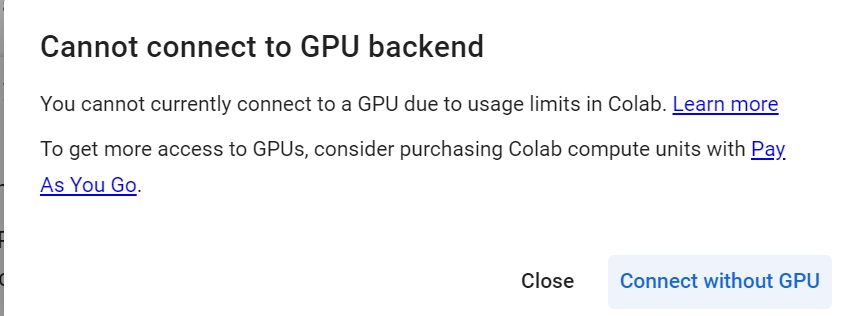

#### Downloading and Loading the model

In [65]:
#NA - Using OPENAI models

# Question Answering using LLM without Prompt Engineering

### Question 1: Who are the authors of this article and who published this article?

In [66]:
question_1 = "Who are the authors of this article and who published this article?"
base_prompt_response_1 = response_without_prompt_engineering(question_1)
base_prompt_response_1

"I’m sorry, but I can't access external content, including specific articles, to provide information on authors or publishers. If you have a specific article in mind, you could provide its title or other details, and I might be able to help with general information or context related to it."

### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [67]:
question_2 = "List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines."
base_prompt_response_2 = response_without_prompt_engineering(question_2)
base_prompt_response_2

'- **Vision**: Effective leaders possess a clear vision of the future and can articulate this vision in a way that inspires others to work towards it. This forward-thinking perspective helps align team efforts and motivates individuals to strive for common goals.\n\n- **Empathy**: Great leaders demonstrate a strong ability to understand and share the feelings of their team members. By fostering a supportive environment, they build trust and encourage open communication, which enhances team cohesion and morale.\n\n- **Decisiveness**: Successful leaders are able to make timely and informed decisions, even in challenging situations. This quality instills confidence in their team, as members feel assured that their leader can navigate uncertainties and guide them effectively.'

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [68]:
question_3 = "Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?"
base_prompt_response_3 = response_without_prompt_engineering(question_3)
base_prompt_response_3

"Certainly! While I can't access specific articles directly, I can provide a general overview of how Apple's leadership approach has historically led to successful innovations, using well-known examples.\n\n1. **Visionary Leadership**: Under Steve Jobs, Apple adopted a visionary leadership style that emphasized bold ideas and a focus on design and user experience. The introduction of the iPhone in 2007 is a prime example. Jobs envisioned a smartphone that combined a phone, an iPod, and an internet communicator. This innovative approach revolutionized the smartphone industry and established Apple as a leader in mobile technology.\n\n2. **Cross-Functional Collaboration**: Apple's leadership encourages collaboration across different departments. For example, the development of the Apple Watch involved teams from hardware, software, and health sectors working together. This collaborative culture resulted in a product that not only functions as a smartwatch but also emphasizes health and fi

## Question Answering using LLM with Prompt Engineering

### Question 1: Who are the authors of this article and who published this article?

In [69]:
question_1 = "Who are the authors of this article and who published this article?"
base_prompt_response_1 = response(system_prompt, question_1)
base_prompt_response_1

'I would need the title or some context about the article you are referring to in order to provide you with the authors and the publisher. Please provide more details.'

### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [70]:
question_2 = "List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines."
base_prompt_response_2 = response(system_prompt, question_2)
base_prompt_response_2

'Sure! Here are three key leadership characteristics:\n\n- **Visionary Thinking**: Effective leaders possess the ability to create and articulate a clear vision for the future, inspiring their teams to work towards common goals and navigate challenges.\n\n- **Emotional Intelligence**: Strong leaders demonstrate high emotional intelligence by understanding their own emotions and those of others, enabling them to manage relationships judiciously and empathetically.\n\n- **Decisiveness**: Successful leaders make timely and well-informed decisions, balancing analysis with intuition, which instills confidence in their teams and drives organizational momentum.'

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [71]:
question_3 = "Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?"
base_prompt_response_3 = response(system_prompt, question_3)
base_prompt_response_3

"I currently do not have access to the specific article you are referencing regarding Apple's approach to leadership and its impact on innovations. To provide you with accurate examples, please share key excerpts or points from the article, and I can help analyze or summarize those details for you."

## Data Preparation for RAG

### Loading the Data

In [72]:
# Uploading multiple pdfs:
from glob import glob

# Path to folder with PDFs

file_path = "HBR_How_Apple_Is_Organized_For_Innovation.pdf"

# Load each PDF file and store the documents
all_documents = []
loader = PyMuPDFLoader(file_path)
documents = loader.load()
all_documents.extend(documents)

### Data Overview

In [73]:
# Loop through the first 5 pages of the PDF content
for i in range(5):
    print(f"Page Number : {i+1}", end="\n")                                     # Print the page number (1-based index)
    print(all_documents[i].page_content, end="\n")                                     # Print the content of the corresponding page

Page Number : 1
REPRINT R2006F
PUBLISHED IN HBR
NOVEMBER–DECEMBER 2020
ARTICLE
ORGANIZATIONAL CULTURE
How Apple Is 
Organized  
for Innovation
It’s about experts leading experts. 
by Joel M. Podolny and Morten T. Hansen
This article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.
Page Number : 2
2
Harvard Business Review
November–December 2020
This article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.
Page Number : 3
PHOTOGRAPHER MIKAEL JANSSON
How Apple Is 
Organized 
for Innovation
It’s about experts 
leading experts.
ORGANIZATIONAL 
CULTURE
Joel M. 
Podolny
Dean, Apple 
University
Morten T. 
Hansen
Faculty, Apple 
University
AUTHORS
FOR ARTICLE REPRINTS CALL 800-988-0886 OR 617-783-7500, OR VISIT HBR.ORG
Harvard Business Review
November–December 2020  3
This article is made available to you with compliment

### Data Chunking

In [74]:
# Initialize a text splitter that uses OpenAI's token encoder
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',                                                # Encoding used by popular LLMs
    chunk_size=256,                                                             # Each chunk will have up to 256 tokens
    chunk_overlap=20                                                            # 20 tokens will overlap between consecutive chunks (for context continuity)
)

In [75]:
# Use the text splitter to divide the PDF content into smaller chunks
document_chunks = loader.load_and_split(text_splitter)                      # Returns a list of chunked documents

In [76]:
print(f"Created {len(document_chunks)} chunks.")

Created 42 chunks.


### Embedding

In [77]:
# Initialize the OpenAI Embeddings model with API credentials
embedding_model = OpenAIEmbeddings(
    openai_api_key=OPENAI_API_KEY,                                                     # Your OpenAI API key for authentication
    openai_api_base=OPENAI_API_BASE                                             # The OpenAI API base URL endpoint
)

# Generate embeddings (vector representations) for the first two document chunks
embedding_1 = embedding_model.embed_query(document_chunks[0].page_content)      # Embedding for chunk 0
embedding_2 = embedding_model.embed_query(document_chunks[1].page_content)      # Embedding for chunk 1

# Check and print the dimension (length) of the embedding vector
print("Dimension of the embedding vector ", len(embedding_1))                   # Typically 1536 or 2048 depending on model

Dimension of the embedding vector  1536


### Vector Database

In [78]:
# Building the vector store and saving it to disk for future use
vectorstore = Chroma.from_documents(
    document_chunks,                                                            # Documents to index
    embedding_model                                                             # Embedding model for converting text to vectors
 )

### Retriever

In [79]:
# Wraping the vector store into a retriever object to fetch the most relevant documents for a given query using similarity search
retriever = vectorstore.as_retriever(
    search_type='similarity',                                                   # Use similarity search (based on vector distance)
    search_kwargs={'k': 5}                                                      # Retrieve top 5 most relevant documents
)

### Response Function

In [80]:
qna_user_message_template = """
###Context
Here are some sources relevant to the question mentioned below:
{context}

###Question
{question}
"""

In [81]:
# Define the system prompt for the model
qna_system_message = """
You are an AI assistant specialized in business analysis, designed to help business analysts efficiently extract key insights from extensive reports.

Your primary goal is to act as an expert business analyst, streamlining the report analysis process for a venture capital firm like Andreesen Horowitz. You should:
- Accurately answer user queries by retrieving highly relevant content directly from lengthy documents.
- Facilitate natural-language interaction, allowing users to get specific information without needing to read the full document.
- Provide an intelligent assistant experience that significantly reduces the time spent on information retrieval and report analysis.

When responding:
- Maintain impeccable factual accuracy and clarity, citing sources or context when appropriate.
- Present insights in a structured, actionable, and business-relevant format, suitable for strategic decision-making.
- Focus on extracting and summarizing key information that directly addresses the user's query.
- Avoid any speculation, inferences, or assumptions that are not explicitly supported by the provided research content.
- If a query requires information not available in the given documents, clearly state that the information cannot be found in the provided context.
- Your responses should empower analysts to make faster, more informed strategic decisions and improve their overall productivity.

Here is an example of how to structure your response:

Answer:
[Answer based on context]

Source:
[Source details with page or section]
"""

In [82]:
def generate_rag_response(user_input,k=5,max_tokens=500,temperature=0.3,top_p=0.95):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=k)
    context_list = [d.page_content for d in relevant_document_chunks]

    # Combine document chunks into a single context
    context_for_query = ". ".join(context_list)

    user_message = qna_user_message_template.replace('{context}', context_for_query)
    user_message = user_message.replace('{question}', user_input)

    # Generate the response
    try:
        response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": qna_system_message},
            {"role": "user", "content": user_message}
        ],
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p
        )
        # Extract and print the generated text from the response
        response = response.choices[0].message.content.strip()
    except Exception as e:
        response = f'Sorry, I encountered the following error: \n {e}'

    return response

## Question Answering using RAG

### Question 1: Who are the authors of this article and who published this article?

In [83]:
response_with_rag_1 = generate_rag_response(question_1)
response_with_rag_1

'Answer:\nThe article is authored by the Harvard Business Review team and published by Harvard Business Review.\n\nSource:\nHarvard Business Review, November–December 2020.'

### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [84]:
response_with_rag_2 = generate_rag_response(question_2)
response_with_rag_2

'Answer:\n- **Deep Expertise**: Leaders are expected to have substantial knowledge in their specific functions, enabling them to engage meaningfully in all related tasks and discussions.\n\n- **Immersion in Details**: Leaders must be deeply involved in the intricacies of their functions, ensuring they understand the nuances that affect decision-making and project outcomes.\n\n- **Collaborative Debate**: Leaders should be willing to engage in open discussions with peers, advocating for their views while remaining receptive to alternative perspectives, fostering a culture of collective decision-making.\n\nSource:\n[Context provided]'

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [85]:
response_with_rag_3 = generate_rag_response(question_3)
response_with_rag_3

"Answer:\nThe article highlights several specific examples of how Apple's approach to leadership has fostered successful innovations:\n\n1. **Organizational Structure Change**: Upon Steve Jobs' return to Apple in 1997, he dismantled the conventional business unit structure that divided the company into separate entities with their own profit and loss responsibilities. This decentralization often led to conflicts among managers. By eliminating the general managers and organizing the company around functions, Jobs created a more collaborative environment where expertise aligned with decision rights. This structural change allowed for faster decision-making and innovation.\n\n2. **Cross-Functional Collaboration**: Apple's leadership model emphasizes cross-functional collaboration among leaders who are deeply knowledgeable about the details of their domains. This collaborative approach enables teams to work together more effectively, share insights, and innovate rapidly, as opposed to bein

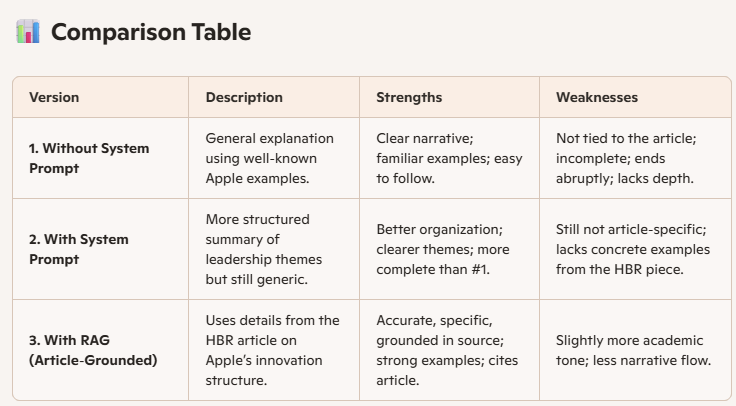![image.png](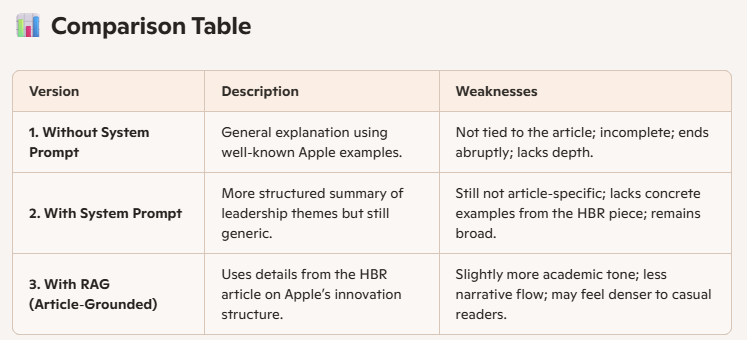)

## Actionable Insights and Business Recommendations

- **Enhance Contextual Continuity:** Adjust the `chunk_overlap` parameter to ensure that nuanced business arguments and organizational frameworks spanning multiple paragraphs are not fragmented. This ensures the retriever maintains the 'narrative' flow of high-level strategic analysis.

- **Uphold Strategic Groundedness:** Continue utilizing strict system prompting to ensure all answers are derived solely from the source report, preventing the LLM from introducing external hallucinations or outdated market data. Additional prompt engineering to adjust the tone of the output.

- **Domain-Specific Embedding Optimization:** Explore embedding models optimized for business and financial terminology to improve the retrieval accuracy of specialized concepts like 'Functional Organization' or 'Decision Rights' mentioned in the HBR report.

- **Dynamic Knowledge Repository:** Regularly ingest the latest industry-specific HBR articles and VC research papers to keep the assistant's context updated with the latest organizational trends and innovation strategies.

- **Multi-Report Synthesis:** Expand the system to allow simultaneous querying across multiple reports, enabling analysts to perform cross-company comparisons or aggregate industry trends efficiently.

- **Analyst Feedback Loop:** Implement a 'citation verification' feature where business analysts can rate the relevance of retrieved sources, allowing for fine-tuning of the retrieval strategy based on professional expertise.

- **Cross-Sector Scalability:** Adapt the RAG framework to support various sectors (e.g., Fintech, Healthcare, SaaS), allowing the venture capital firm to apply the same high-speed insights extraction to their entire investment portfolio.